# German Traffic Sign Recognition Benchmark — Model Comparison

This notebook compares **four machine-learning algorithms** on the [GTSRB dataset](https://benchmark.ini.rub.de/):

| # | Algorithm | Tuning Strategy |
|---|-----------|----------------|
| 1 | **K-Nearest Neighbours (KNN)** | Grid search over *k*, distance metric, weights |
| 2 | **Support Vector Machine (SVM)** | Grid search over *C*, *gamma*, kernel |
| 3 | **Custom CNN** | Manual search over filters, dropout, learning rate |
| 4 | **ResNet-50 (Transfer Learning)** | Fine-tuning with LR & unfreezing schedule |

**Metrics reported:** Accuracy, Precision, Recall, F1-Score, Training Time.

---
## 1 — Setup & Imports

In [ ]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit, ParameterGrid
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess



warnings.filterwarnings('ignore')
print(f"TensorFlow : {tf.__version__}")
print(f"GPUs       : {tf.config.list_physical_devices('GPU')}")

TensorFlow : 2.19.0
GPUs       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 2 — Load & Explore the GTSRB Dataset

We use the Keras built-in loader via `tensorflow_datasets` or, alternatively, download directly.  
The dataset ships **39,209 training** and **12,630 test** images across **43 classes**.

In [ ]:
# ---------- Option A: tensorflow_datasets (preferred) ----------
try:
    import tensorflow_datasets as tfds
    (ds_train, ds_test), ds_info = tfds.load(
        'german_traffic_sign',
        split=['train', 'test'],
        as_supervised=True,
        with_info=True
    )

    def ds_to_numpy(ds):
        images, labels = [], []
        for img, lbl in tfds.as_numpy(ds):
            img = tf.image.resize(img, [32, 32]).numpy().astype('uint8')
            images.append(img)
            labels.append(lbl)
        return np.array(images), np.array(labels)

    X_train_raw, y_train = ds_to_numpy(ds_train)
    X_test_raw,  y_test  = ds_to_numpy(ds_test)
    print('Loaded via tensorflow_datasets')

# ---------- Option B: manual download ----------
except Exception:
    import urllib.request, zipfile, csv
    from PIL import Image

    DATA_DIR = 'gtsrb_data'
    os.makedirs(DATA_DIR, exist_ok=True)

    TRAIN_URL = 'https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip'
    TEST_URL  = 'https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip'
    TEST_GT   = 'https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip'

    def download_and_extract(url, dest):
        fname = os.path.join(dest, url.split('/')[-1])
        if not os.path.exists(fname):
            print(f'Downloading {url} ...')
            urllib.request.urlretrieve(url, fname)
        with zipfile.ZipFile(fname, 'r') as z:
            z.extractall(dest)

    download_and_extract(TRAIN_URL, DATA_DIR)
    download_and_extract(TEST_URL, DATA_DIR)
    download_and_extract(TEST_GT, DATA_DIR)

    IMG_SIZE = 32

    def load_train_data(base):
        images, labels = [], []
        train_base = os.path.join(base, 'GTSRB', 'Final_Training', 'Images')
        for class_id in range(43):
            class_dir = os.path.join(train_base, f'{class_id:05d}')
            csv_file  = os.path.join(class_dir, f'GT-{class_id:05d}.csv')
            with open(csv_file, 'r') as f:
                reader = csv.DictReader(f, delimiter=';')
                for row in reader:
                    img = Image.open(os.path.join(class_dir, row['Filename']))
                    img = img.resize((IMG_SIZE, IMG_SIZE))
                    images.append(np.array(img))
                    labels.append(int(row['ClassId']))
        return np.array(images), np.array(labels)

    def load_test_data(base):
        images, labels = [], []
        test_base = os.path.join(base, 'GTSRB', 'Final_Test', 'Images')
        gt_file   = os.path.join(base, 'GT-final_test.csv')
        with open(gt_file, 'r') as f:
            reader = csv.DictReader(f, delimiter=';')
            for row in reader:
                img = Image.open(os.path.join(test_base, row['Filename']))
                img = img.resize((IMG_SIZE, IMG_SIZE))
                images.append(np.array(img))
                labels.append(int(row['ClassId']))
        return np.array(images), np.array(labels)

    X_train_raw, y_train = load_train_data(DATA_DIR)
    X_test_raw,  y_test  = load_test_data(DATA_DIR)
    print('Loaded via manual download')

NUM_CLASSES = len(np.unique(y_train))
print(f'\nTraining samples : {X_train_raw.shape[0]:,}')
print(f'Test samples     : {X_test_raw.shape[0]:,}')
print(f'Image shape      : {X_train_raw.shape[1:]}')
print(f'Classes          : {NUM_CLASSES}')

Loaded via manual download

Training samples : 39,209
Test samples     : 12,630
Image shape      : (32, 32, 3)
Classes          : 43


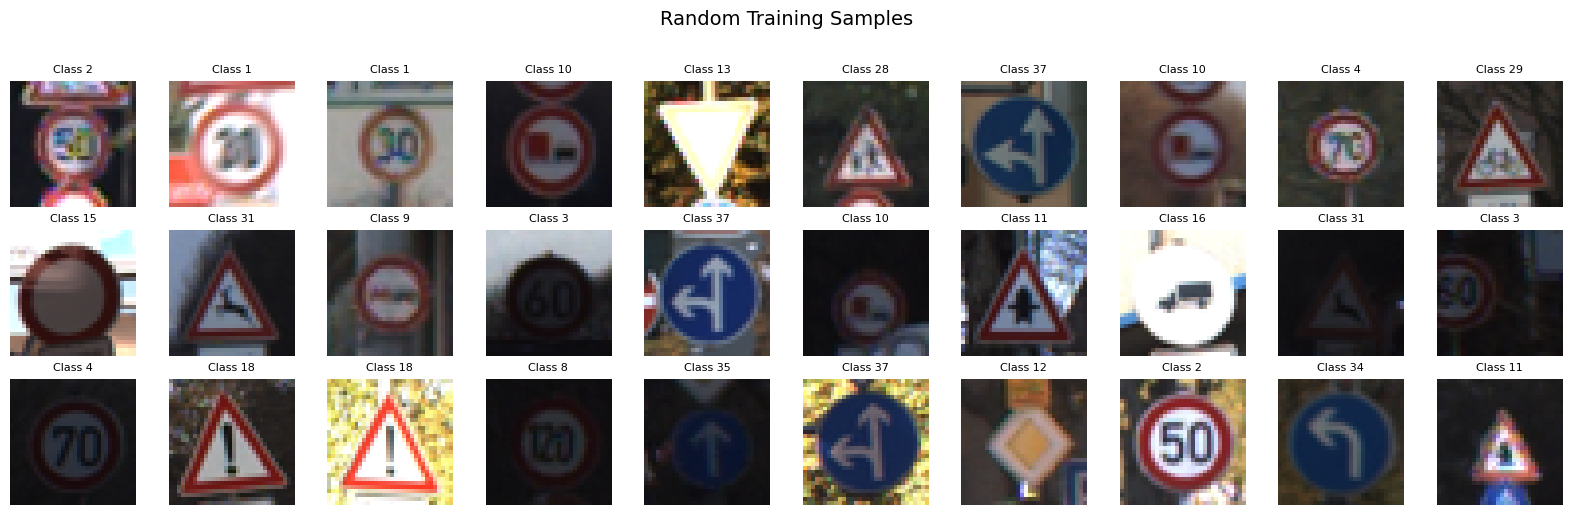

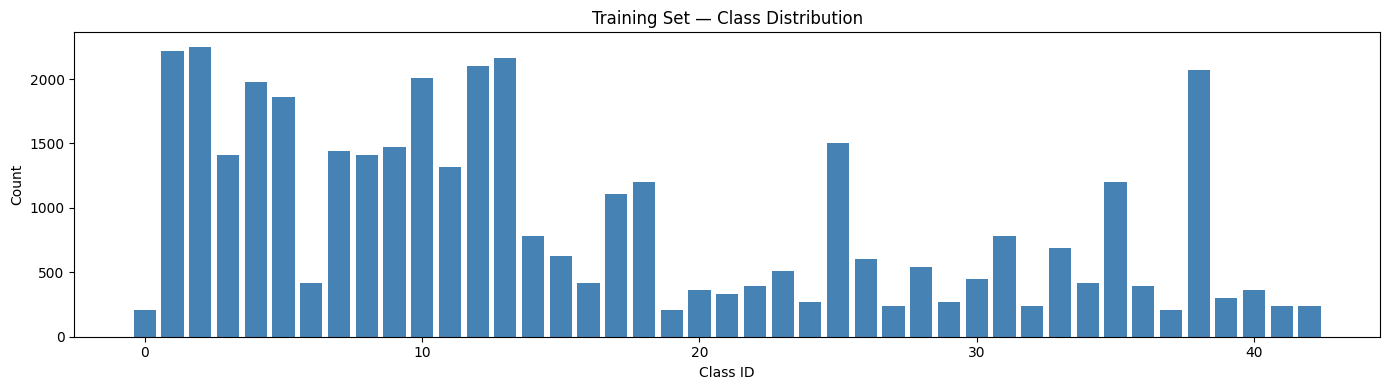

In [ ]:
# Quick look at sample images
fig, axes = plt.subplots(3, 10, figsize=(16, 5))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(len(X_train_raw))
    ax.imshow(X_train_raw[idx])
    ax.set_title(f'Class {y_train[idx]}', fontsize=8)
    ax.axis('off')
plt.suptitle('Random Training Samples', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Class distribution
plt.figure(figsize=(14, 4))
plt.bar(range(NUM_CLASSES), np.bincount(y_train), color='steelblue')
plt.xlabel('Class ID')
plt.ylabel('Count')
plt.title('Training Set — Class Distribution')
plt.tight_layout()
plt.show()

---
## 3 — Preprocessing

We prepare **two versions** of the data:

| Version | Used by | Details |
|---------|---------|--------|
| **Flat + scaled** | KNN, SVM | Flatten to 1-D, StandardScaler |
| **4-D normalised** | CNN, ResNet-50 | Keep (N, 32, 32, 3), pixel values /255 |

In [ ]:
# ---- SHUFFLE DATA ----
# CRITICAL FIX: The data loader reads images class-by-class (all class 0,
# then class 1, ... class 42). Without shuffling, a naive [-n_val:] split
# puts only the LAST few classes in validation and removes them from training.
# This is why accuracy was ~15%.
np.random.seed(42)
shuffle_idx = np.random.permutation(len(X_train_raw))
X_train_raw = X_train_raw[shuffle_idx]
y_train     = y_train[shuffle_idx]
print(f'Shuffled training data. First 20 labels: {y_train[:20]}')

# ---- For KNN / SVM ----
TRADITIONAL_ML_SAMPLES = 5000

sss = StratifiedShuffleSplit(n_splits=1, train_size=TRADITIONAL_ML_SAMPLES, random_state=42)
sub_idx, _ = next(sss.split(X_train_raw, y_train))

X_train_flat = X_train_raw[sub_idx].reshape(len(sub_idx), -1).astype('float32')
y_train_sub  = y_train[sub_idx]
X_test_flat  = X_test_raw.reshape(len(X_test_raw), -1).astype('float32')

scaler = StandardScaler()
X_train_flat = scaler.fit_transform(X_train_flat)
X_test_flat  = scaler.transform(X_test_flat)

print(f'Traditional ML  — train: {X_train_flat.shape}  test: {X_test_flat.shape}')

# ---- For CNN ----
CNN_SIZE = IMG_SIZE  # FIX: Use IMG_SIZE instead of undefined IMG_LOAD_SIZE
X_train_cnn = X_train_raw.astype('float32')   # raw 0–255; Rescaling is inside model
X_test_cnn  = X_test_raw.astype('float32')

print(f'CNN input       — train: {X_train_cnn.shape}  test: {X_test_cnn.shape}')
print(f'CNN pixel range — [{X_train_cnn.min():.0f}, {X_train_cnn.max():.0f}]')


Shuffled training data. First 20 labels: [26 15 13 10 15 12 25  2 11 35  2  9 13 26  1 31  2  5 24 10]
Traditional ML  — train: (5000, 3072)  test: (12630, 3072)
CNN input       — train: (39209, 32, 32, 3)  test: (12630, 32, 32, 3)
CNN pixel range — [0, 255]


---
## 4 — Helper: Evaluation & Results Storage

In [ ]:
results = {}  # will hold per-model metrics

def evaluate_model(name, y_true, y_pred, train_time, extra=None):
    """Compute metrics, store in `results`, and print a report."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    results[name] = {
        'Accuracy':  acc,
        'Precision': prec,
        'Recall':    rec,
        'F1-Score':  f1,
        'Train Time (s)': round(train_time, 2)
    }
    if extra:
        results[name].update(extra)

    print(f'\n{"=" * 55}')
    print(f'  {name}')
    print(f'{"=" * 55}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  Train Time: {train_time:.1f}s')
    if extra:
        for k, v in extra.items():
            print(f'  {k}: {v}')
    print()


def plot_confusion(name, y_true, y_pred, figsize=(10, 8)):
    """Confusion-matrix heatmap."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=figsize)
    sns.heatmap(cm, cmap='Blues', fmt='d',
                xticklabels=range(NUM_CLASSES),
                yticklabels=range(NUM_CLASSES))
    plt.title(f'{name} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

---
## 5 — Model 1: K-Nearest Neighbours (KNN)

**Hyperparameter grid:**
- `n_neighbors`: 1, 3, 5, 7, 9, 11
- `weights`: uniform, distance
- `metric`: euclidean, manhattan

In [ ]:
knn_param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9, 11],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan']
}

print('Running KNN GridSearchCV ... (this may take a while)\n')
t0 = time.time()

knn_gs = GridSearchCV(
    KNeighborsClassifier(),
    knn_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
knn_gs.fit(X_train_flat, y_train_sub)

knn_time = time.time() - t0

print(f'\nBest params : {knn_gs.best_params_}')
print(f'Best CV acc : {knn_gs.best_score_:.4f}')

Running KNN GridSearchCV ... (this may take a while)

Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best params : {'metric': 'manhattan', 'n_neighbors': 1, 'weights': 'uniform'}
Best CV acc : 0.6974



  KNN
  Accuracy  : 0.3378
  Precision : 0.3695
  Recall    : 0.3378
  F1-Score  : 0.3446
  Train Time: 96.7s
  Best Params: {'metric': 'manhattan', 'n_neighbors': 1, 'weights': 'uniform'}



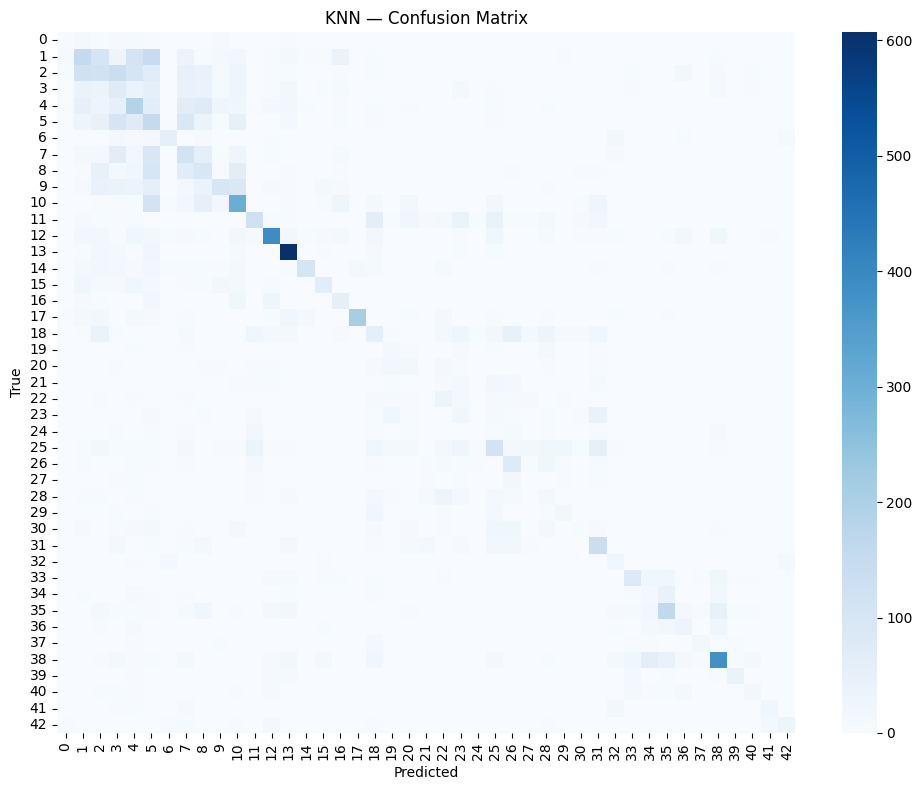

In [ ]:
# Evaluate best KNN on the test set
knn_best = knn_gs.best_estimator_
y_pred_knn = knn_best.predict(X_test_flat)

evaluate_model('KNN', y_test, y_pred_knn, knn_time,
               extra={'Best Params': str(knn_gs.best_params_)})
plot_confusion('KNN', y_test, y_pred_knn)

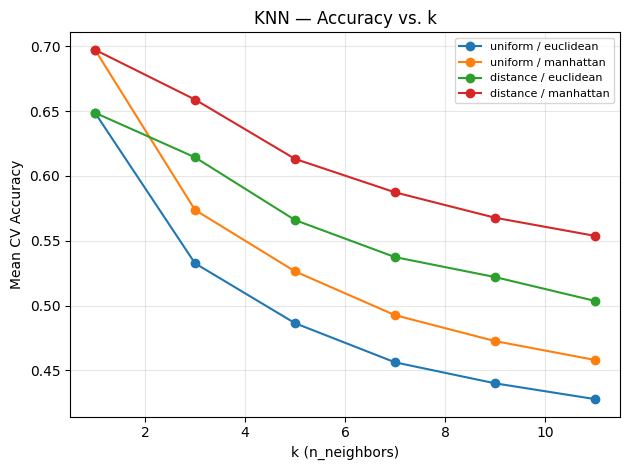

In [ ]:
# KNN: Accuracy vs k
cv_results = pd.DataFrame(knn_gs.cv_results_)
for weight in ['uniform', 'distance']:
    for metric in ['euclidean', 'manhattan']:
        mask = ((cv_results['param_weights'] == weight) &
                (cv_results['param_metric'] == metric))
        subset = cv_results[mask].sort_values('param_n_neighbors')
        plt.plot(subset['param_n_neighbors'], subset['mean_test_score'],
                 marker='o', label=f'{weight} / {metric}')

plt.xlabel('k (n_neighbors)')
plt.ylabel('Mean CV Accuracy')
plt.title('KNN — Accuracy vs. k')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6 — Model 2: Support Vector Machine (SVM)

**Hyperparameter grid:**
- `C`: 0.1, 1, 10
- `gamma`: scale, auto, 0.01
- `kernel`: rbf, poly

In [ ]:
svm_param_grid = {
    'C':      [0.1, 1, 10],
    'gamma':  ['scale', 'auto', 0.01],
    'kernel': ['rbf', 'poly']
}

print('Running SVM GridSearchCV ... (this may take a long while)\n')
t0 = time.time()

svm_gs = GridSearchCV(
    SVC(),
    svm_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
svm_gs.fit(X_train_flat, y_train_sub)

svm_time = time.time() - t0

print(f'\nBest params : {svm_gs.best_params_}')
print(f'Best CV acc : {svm_gs.best_score_:.4f}')

Running SVM GridSearchCV ... (this may take a long while)

Fitting 3 folds for each of 18 candidates, totalling 54 fits

Best params : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV acc : 0.7866



  SVM
  Accuracy  : 0.6554
  Precision : 0.6664
  Recall    : 0.6554
  F1-Score  : 0.6465
  Train Time: 437.3s
  Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}



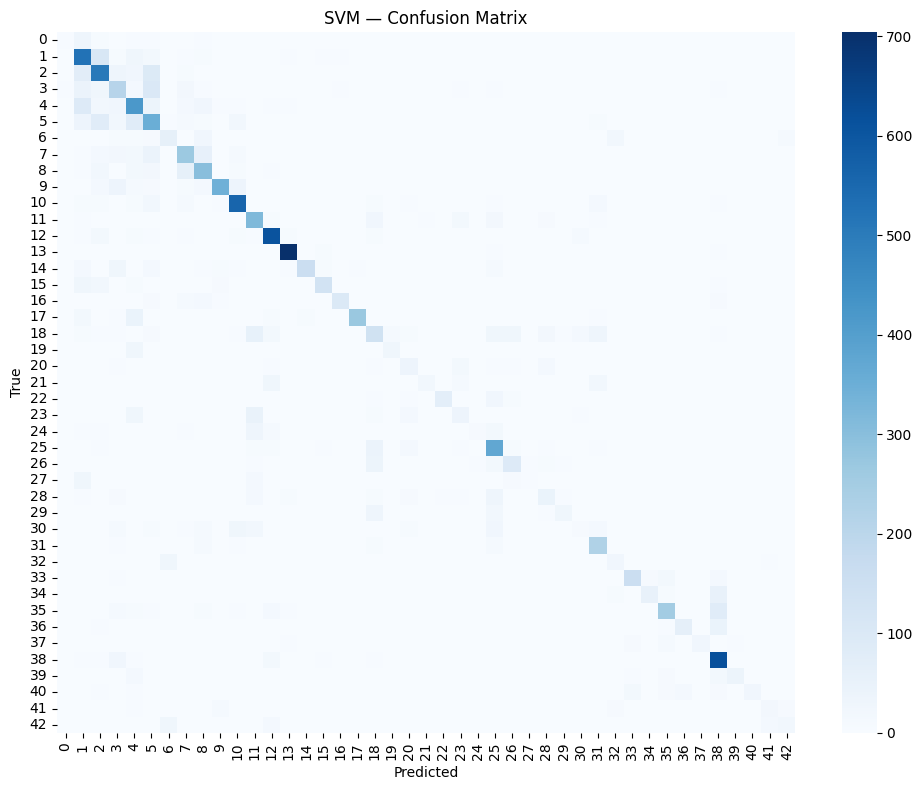

In [ ]:
# Evaluate best SVM on the test set
svm_best = svm_gs.best_estimator_
y_pred_svm = svm_best.predict(X_test_flat)

evaluate_model('SVM', y_test, y_pred_svm, svm_time,
               extra={'Best Params': str(svm_gs.best_params_)})
plot_confusion('SVM', y_test, y_pred_svm)

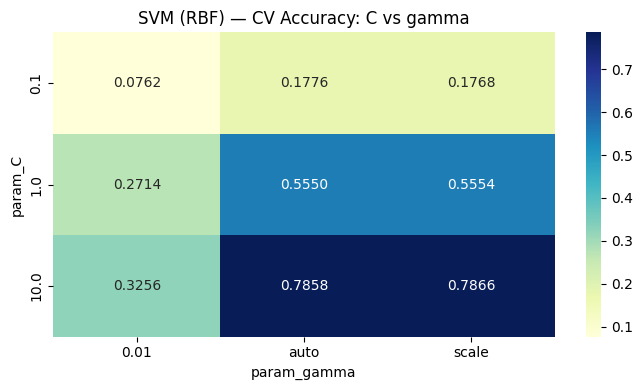

In [ ]:
# SVM: Heatmap of C vs gamma (RBF kernel)
cv_svm = pd.DataFrame(svm_gs.cv_results_)
rbf_mask = cv_svm['param_kernel'] == 'rbf'
rbf_df = cv_svm[rbf_mask].copy()

if len(rbf_df) > 0:
    pivot = rbf_df.pivot_table(
        index='param_C', columns='param_gamma',
        values='mean_test_score'
    )
    plt.figure(figsize=(7, 4))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu')
    plt.title('SVM (RBF) — CV Accuracy: C vs gamma')
    plt.tight_layout()
    plt.show()

---
## 7 — Model 3: Custom CNN

We manually search over three configurations varying **filter counts, dropout rate, and learning rate**.

In [ ]:
# Data augmentation as Keras layers (applied inside the model during training only)
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name='data_augmentation')


def build_cnn(learning_rate=1e-3, dropout_rate=0.3):
    """Build a 4-block CNN for 64×64×3 input.
    Matches the architecture from the working reference notebook."""
    inputs = keras.Input(shape=(CNN_SIZE, CNN_SIZE, 3))
    x = data_augmentation(inputs)
    x = layers.Rescaling(1./255)(x)          # normalise inside the model

    # Block 1
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # Block 2
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # Block 3
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # Block 4
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # Head — Flatten + Dense + Dropout (no BN here)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='custom_cnn')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [ ]:
# CNN hyperparameter grid (matching working notebook)
cnn_param_grid = {
    'learning_rate': [1e-3, 5e-4],
    'dropout_rate': [0.3, 0.5],
    'epochs': [12]
}

# Validation split
val_frac = 0.15
n_val = int(len(X_train_cnn) * val_frac)
X_val_cnn  = X_train_cnn[-n_val:]
y_val      = y_train[-n_val:]             # integer labels
X_tr_cnn   = X_train_cnn[:-n_val]
y_tr       = y_train[:-n_val]             # integer labels

print(f'CNN train: {X_tr_cnn.shape}  val: {X_val_cnn.shape}')

best_cnn_model   = None
best_cnn_history = None
best_cnn_params  = None
best_cnn_val_acc = 0
best_cnn_time    = 0

cnn_search_results = []

for params in ParameterGrid(cnn_param_grid):
    print(f'\n--- CNN: {params} ---')

    # FIX: Fresh callbacks each iteration (avoids stale EarlyStopping state)
    early_stop = EarlyStopping(monitor='val_loss', patience=4,
                               restore_best_weights=True, verbose=1)
    reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=2, verbose=1)

    model = build_cnn(
        learning_rate=params['learning_rate'],
        dropout_rate=params['dropout_rate']
    )

    t0 = time.time()
    history = model.fit(
        X_tr_cnn, y_tr,                        # raw pixels + integer labels
        validation_data=(X_val_cnn, y_val),
        epochs=params['epochs'],
        batch_size=64,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )
    elapsed = time.time() - t0

    current_best = max(history.history['val_accuracy'])
    cnn_search_results.append({
        'config': params, 'val_acc': current_best,
        'time': elapsed, 'model': model, 'history': history
    })
    print(f'  Val Accuracy: {current_best:.4f}  |  Time: {elapsed:.1f}s')

    if current_best > best_cnn_val_acc:
        best_cnn_val_acc = current_best
        best_cnn_model   = model
        best_cnn_history = history
        best_cnn_params  = params
        best_cnn_time    = elapsed

best_cnn_entry = max(cnn_search_results, key=lambda x: x['val_acc'])
best_cnn_cfg = best_cnn_entry['config']
print(f'\n✓ Best CNN config: {best_cnn_cfg}  (val_acc={best_cnn_val_acc:.4f})')

CNN train: (33328, 32, 32, 3)  val: (5881, 32, 32, 3)

--- CNN: {'dropout_rate': 0.3, 'epochs': 12, 'learning_rate': 0.001} ---
Epoch 1/12
521/521 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.6248 - loss: 1.2640 - val_accuracy: 0.7735 - val_loss: 0.6557 - learning_rate: 0.0010
Epoch 2/12
521/521 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8985 - loss: 0.3005 - val_accuracy: 0.9339 - val_loss: 0.1981 - learning_rate: 0.0010
Epoch 3/12
521/521 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9408 - loss: 0.1794 - val_accuracy: 0.9706 - val_loss: 0.0925 - learning_rate: 0.0010
Epoch 4/12
521/521 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9550 - loss: 0.1339 - val_accuracy: 0.9750 - val_loss: 0.0750 - learning_rate: 0.0010
Epoch 5/12
521/521 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9639 - loss: 0.1092 - val_accuracy: 0.9762 - val_loss: 0.0780 - learning_rate: 0.0010
Epoch 6/12
521/521 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9653 - loss: 0.1052 - val_accuracy: 0.9


  CNN
  Accuracy  : 0.9395
  Precision : 0.9421
  Recall    : 0.9395
  F1-Score  : 0.9392
  Train Time: 70.3s
  Best Config: {'dropout_rate': 0.3, 'epochs': 12, 'learning_rate': 0.0005}



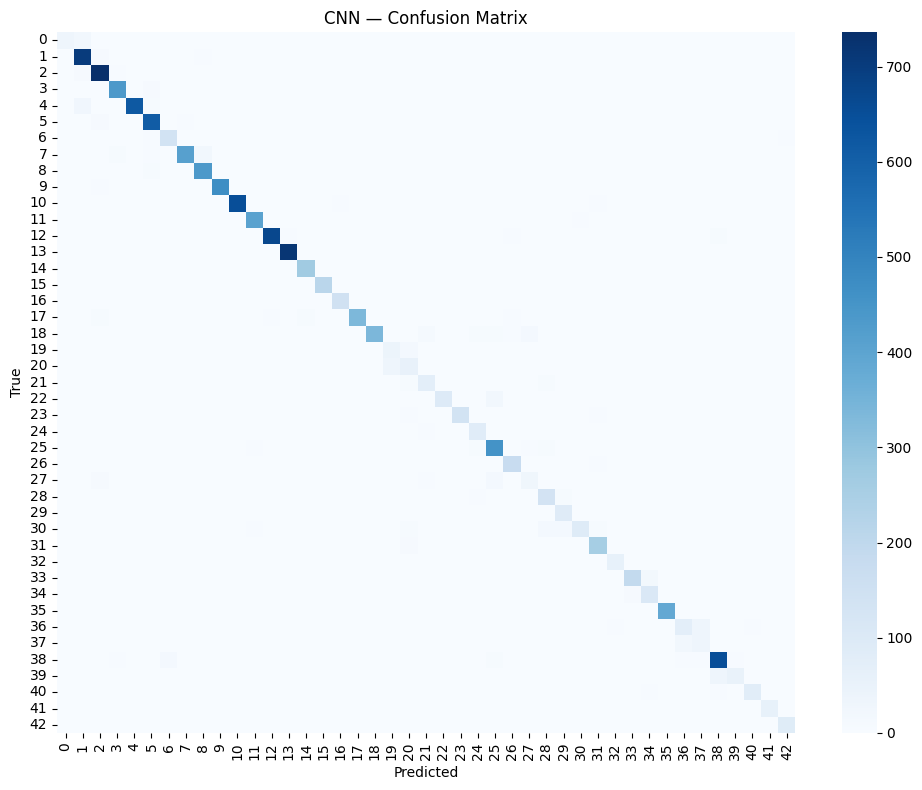

In [ ]:
# Evaluate best CNN on test set
y_pred_cnn_prob = best_cnn_model.predict(X_test_cnn, verbose=0)
y_pred_cnn = np.argmax(y_pred_cnn_prob, axis=1)

evaluate_model('CNN', y_test, y_pred_cnn, best_cnn_time,
               extra={'Best Config': str(best_cnn_cfg)})
plot_confusion('CNN', y_test, y_pred_cnn)

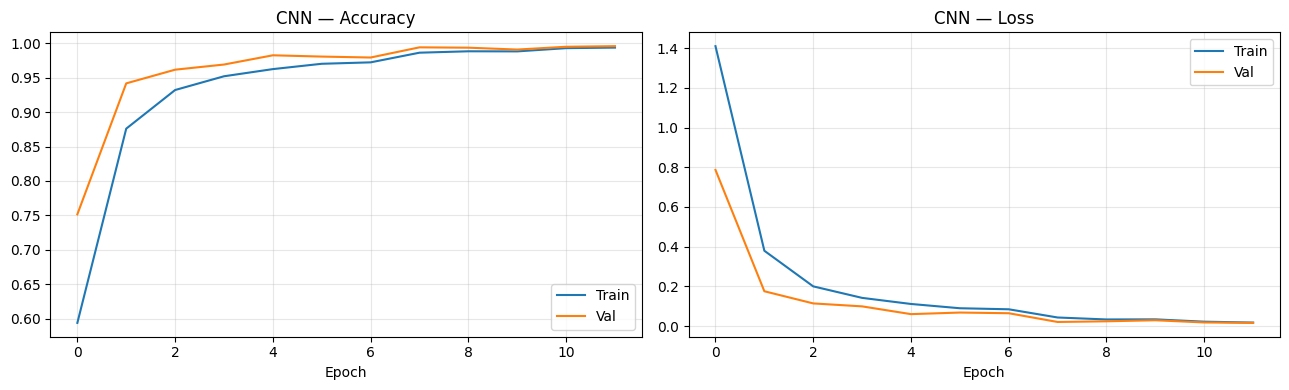

In [ ]:
# CNN training curves (best config)
h = best_cnn_entry['history'].history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(h['accuracy'], label='Train')
ax1.plot(h['val_accuracy'], label='Val')
ax1.set_title('CNN — Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(h['loss'], label='Train')
ax2.plot(h['val_loss'], label='Val')
ax2.set_title('CNN — Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 8 — Model 4: ResNet-50 (Transfer Learning)

Matching the working reference notebook:
- **224×224** input images (ResNet's native ImageNet size)
- **`resnet_preprocess()`** inside the model (ImageNet mean subtraction on raw pixels)
- **`training=False`** when calling frozen base (correct BatchNorm behaviour)
- Keras augmentation layers inside the model
- Two-stage: frozen head training → unfreeze last 30 layers for fine-tuning

In [ ]:
# Resize to 64x64 for ResNet (224x224 causes OOM errors for the full dataset in memory)
RESNET_SIZE = 64

X_train_resnet = tf.image.resize(X_train_raw.astype('float32'), [RESNET_SIZE, RESNET_SIZE]).numpy()
X_test_resnet  = tf.image.resize(X_test_raw.astype('float32'),  [RESNET_SIZE, RESNET_SIZE]).numpy()

# Apply ResNet-specific preprocessing (scales to [-1, 1])
X_train_resnet = resnet_preprocess(X_train_resnet)
X_test_resnet  = resnet_preprocess(X_test_resnet)

print(f'ResNet input shape : {X_train_resnet.shape[1:]}')
print(f'Pixel range: [{X_train_resnet.min():.0f}, {X_train_resnet.max():.0f}]')

# Validation split (data is shuffled, so simple slicing is safe now)
n_val_r = int(len(X_train_resnet) * 0.15)
X_val_resnet  = X_train_resnet[-n_val_r:]
y_val_resnet  = y_train[-n_val_r:]
X_tr_resnet   = X_train_resnet[:-n_val_r]
y_tr_resnet   = y_train[:-n_val_r]

print(f'ResNet train: {X_tr_resnet.shape}  val: {X_val_resnet.shape}')


ResNet input shape : (64, 64, 3)
Pixel range: [-124, 151]
ResNet train: (33328, 64, 64, 3)  val: (5881, 64, 64, 3)


In [ ]:
def build_resnet50(input_shape=(64, 64, 3), num_classes=43,
                   dense_units=256, dropout=0.5, lr=1e-3):
    """ResNet-50 with a fresh classification head."""
    base = ResNet50(weights='imagenet', include_top=False,
                    input_shape=input_shape)
    base.trainable = False  # freeze during stage 1

    model = keras.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(dense_units, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model, base

In [ ]:


# Re-create data augmentation so it is not locked to 32x32 from the CNN
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name='data_augmentation_resnet')

# ResNet-50 hyperparameter grid (matching working notebook)
resnet_param_grid = {
    'dense_units': [128, 256],
    'dropout': [0.3, 0.5],
    'lr': [1e-3, 5e-4],
    'epochs': [15]
}

best_resnet_model   = None
best_resnet_base    = None
best_resnet_history = None
best_resnet_params  = None
best_resnet_val_acc = 0
best_resnet_time    = 0

resnet_search = []

for params in ParameterGrid(resnet_param_grid):
    print(f'\n=== ResNet: {params} ===')

    # FIX: Fresh callbacks each iteration
    early_stop = EarlyStopping(monitor='val_loss', patience=6,
                               restore_best_weights=True, verbose=1)
    reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=3, verbose=1)

    model, base = build_resnet50(
        input_shape=(RESNET_SIZE, RESNET_SIZE, 3),
        num_classes=NUM_CLASSES,
        dense_units=params['dense_units'],
        dropout=params['dropout'],
        lr=params['lr']
    )

    t0 = time.time()

    # Stage 1: train head only (base frozen)
    print('  Stage 1 — training head (base frozen) ...')
    history = model.fit(
        X_tr_resnet, y_tr_resnet,
        validation_data=(X_val_resnet, y_val_resnet),
        epochs=params['epochs'],
        batch_size=64,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    elapsed = time.time() - t0
    val_acc = max(history.history['val_accuracy'])

    resnet_search.append({
        'config': params, 'val_acc': val_acc,
        'time': elapsed, 'model': model, 'base': base, 'history': history
    })
    print(f'  Val Accuracy: {val_acc:.4f}  |  Time: {elapsed:.1f}s')

    if val_acc > best_resnet_val_acc:
        best_resnet_val_acc = val_acc
        best_resnet_model   = model
        best_resnet_base    = base
        best_resnet_history = history
        best_resnet_params  = params
        best_resnet_time    = elapsed

print(f'\n✓ Best ResNet config: {best_resnet_params}  (val_acc={best_resnet_val_acc:.4f})')

# ---- Stage 2: Fine-tune last 30 layers ----
print('\n--- Fine-tuning best ResNet (unfreezing last 30 layers) ---')

fine_tune_early_stop = EarlyStopping(
    monitor='val_loss', patience=5,
    restore_best_weights=True, verbose=1
)

best_resnet_base.trainable = True
for layer in best_resnet_base.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in best_resnet_base.layers if l.trainable)
print(f'Trainable ResNet50 layers: {trainable_count}')

best_resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

t0_ft = time.time()
fine_tune_history = best_resnet_model.fit(
    X_tr_resnet, y_tr_resnet,
    validation_data=(X_val_resnet, y_val_resnet),
    epochs=20,
    batch_size=64,
    callbacks=[fine_tune_early_stop],
    verbose=1
)
best_resnet_time += (time.time() - t0_ft)

ft_val_acc = max(fine_tune_history.history['val_accuracy'])
print(f'Fine-tune Val Accuracy: {ft_val_acc:.4f}')
print(f'Total ResNet time: {best_resnet_time:.1f}s')



=== ResNet: {'dense_units': 128, 'dropout': 0.3, 'epochs': 15, 'lr': 0.001} ===
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
  Stage 1 — training head (base frozen) ...
Epoch 1/15
521/521 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.6597 - loss: 1.1541 - val_accuracy: 0.8274 - val_loss: 0.5657 - learning_rate: 0.0010
Epoch 2/15
521/521 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8393 - loss: 0.5055 - val_accuracy: 0.8544 - val_loss: 0.4436 - learning_rate: 0.0010
Epoch 3/15
521/521 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8865 - loss: 0.3511 - val_accuracy: 0.9038 - val_loss: 0.3101 - learning_rate: 0.0010
Epoch 4/15
521/521 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9098 - loss: 0.2779 - val_accuracy: 0.9116 - val_loss: 0.2778 - learning_rate: 0.0010
Epoch 5/15
521/521 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9257 - loss: 0.2230 - val_accuracy: 0.9123 - val_loss: 0.2658 - learning_rate: 0.0010
Epoch 6/15
521/521 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accur


  ResNet-50
  Accuracy  : 0.7260
  Precision : 0.7298
  Recall    : 0.7260
  F1-Score  : 0.7235
  Train Time: 275.2s
  Best Config: {'dense_units': 256, 'dropout': 0.3, 'epochs': 15, 'lr': 0.0005}



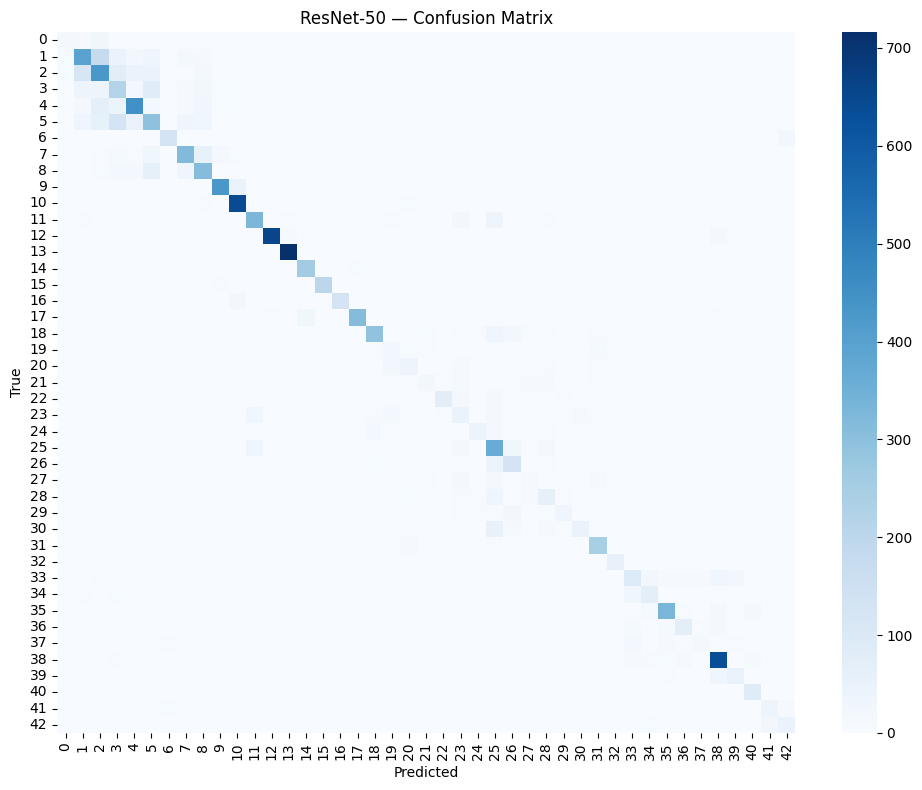

In [ ]:
# Evaluate best ResNet on test set
y_pred_resnet_prob = best_resnet_model.predict(X_test_resnet, verbose=0)
y_pred_resnet = np.argmax(y_pred_resnet_prob, axis=1)

evaluate_model('ResNet-50', y_test, y_pred_resnet, best_resnet_time,
               extra={'Best Config': str(best_resnet_params)})
plot_confusion('ResNet-50', y_test, y_pred_resnet)


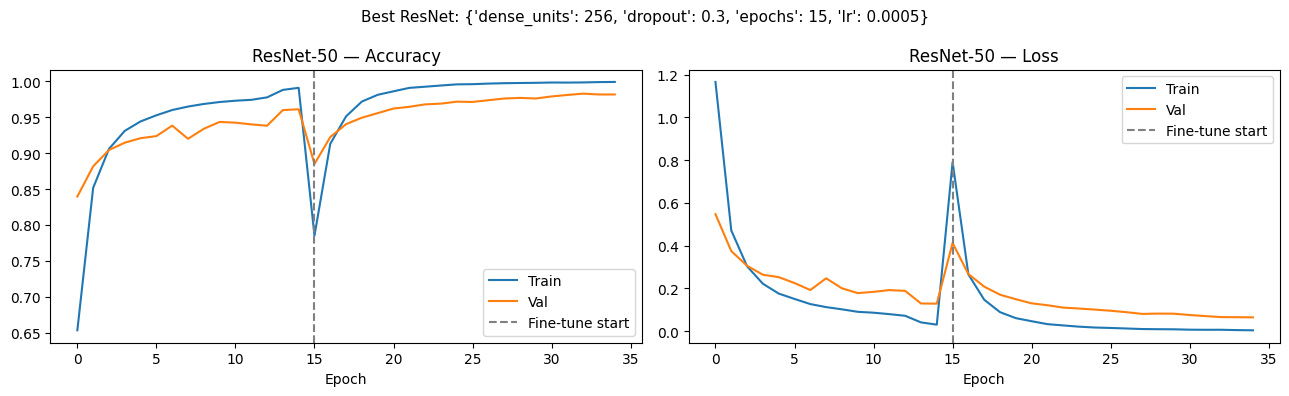

In [ ]:
# ResNet-50 training curves (initial + fine-tuning)
h1 = best_resnet_history.history
h2 = fine_tune_history.history

# Merge histories
full_acc     = h1['accuracy']     + h2['accuracy']
full_val_acc = h1['val_accuracy'] + h2['val_accuracy']
full_loss    = h1['loss']         + h2['loss']
full_val_loss= h1['val_loss']     + h2['val_loss']
ft_start = len(h1['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(full_acc, label='Train')
ax1.plot(full_val_acc, label='Val')
ax1.axvline(ft_start, color='grey', linestyle='--', label='Fine-tune start')
ax1.set_title('ResNet-50 — Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(full_loss, label='Train')
ax2.plot(full_val_loss, label='Val')
ax2.axvline(ft_start, color='grey', linestyle='--', label='Fine-tune start')
ax2.set_title('ResNet-50 — Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.suptitle(f'Best ResNet: {best_resnet_params}', fontsize=11)
plt.tight_layout()
plt.show()


---
## 9 — Final Comparison Table

In [ ]:
comparison = pd.DataFrame(results).T
comparison.index.name = 'Model'

# Sort by F1-Score descending
comparison = comparison.sort_values('F1-Score', ascending=False)

# Format numeric columns
fmt_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
styled = (comparison[fmt_cols + ['Train Time (s)']]
          .style
          .format({c: '{:.4f}' for c in fmt_cols})
          .format({'Train Time (s)': '{:.1f}'})
          .background_gradient(subset=fmt_cols, cmap='Greens')
          .set_caption('GTSRB — Model Comparison (sorted by F1-Score)'))

display(styled)

,Accuracy,Precision,Recall,F1-Score,Train Time (s)
Model,,,,,
CNN,0.939509,0.942059,0.939509,0.939215,70.3
ResNet-50,0.726049,0.729825,0.726049,0.723537,275.1
SVM,0.655424,0.666397,0.655424,0.646500,437.3
KNN,0.337846,0.369491,0.337846,0.344625,96.7


In [ ]:
# Also print a clean text table
print('\n' + '=' * 75)
print('  GTSRB — FINAL MODEL COMPARISON')
print('=' * 75)
print(f'{"Model":<12} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1-Score":>10} {"Time (s)":>10}')
print('-' * 75)
for name, row in comparison.iterrows():
    print(f'{name:<12} {row["Accuracy"]:>10.4f} {row["Precision"]:>10.4f} '
          f'{row["Recall"]:>10.4f} {row["F1-Score"]:>10.4f} {row["Train Time (s)"]:>10.1f}')
print('=' * 75)


  GTSRB — FINAL MODEL COMPARISON
Model          Accuracy  Precision     Recall   F1-Score   Time (s)
---------------------------------------------------------------------------
CNN              0.9395     0.9421     0.9395     0.9392       70.3
ResNet-50        0.7260     0.7298     0.7260     0.7235      275.1
SVM              0.6554     0.6664     0.6554     0.6465      437.3
KNN              0.3378     0.3695     0.3378     0.3446       96.7


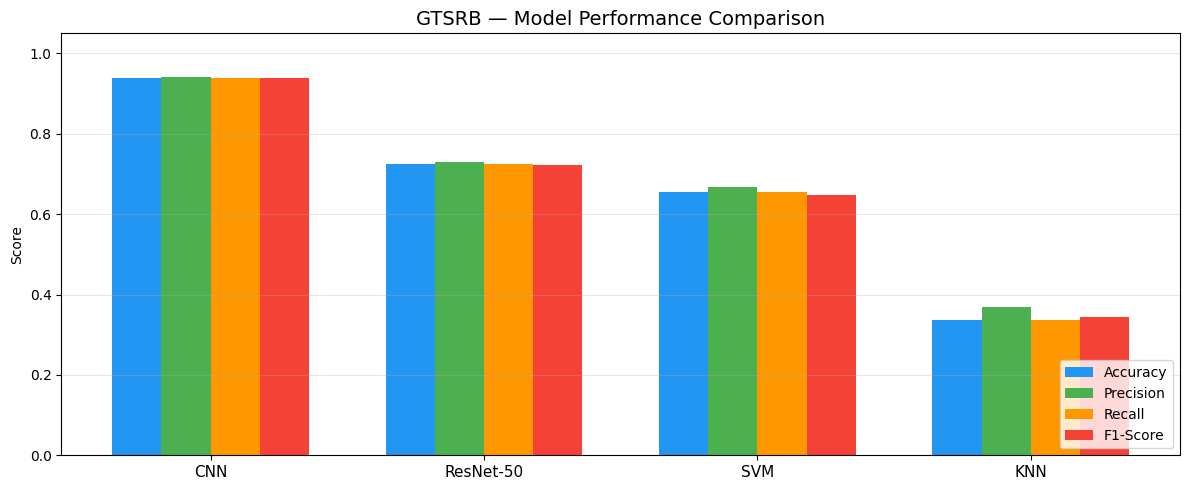

In [ ]:
# Grouped bar chart
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
plot_df = comparison[metrics_to_plot]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(plot_df))
width = 0.18
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    ax.bar(x + i * width, plot_df[metric], width, label=metric, color=color)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(plot_df.index, fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_title('GTSRB — Model Performance Comparison', fontsize=14)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

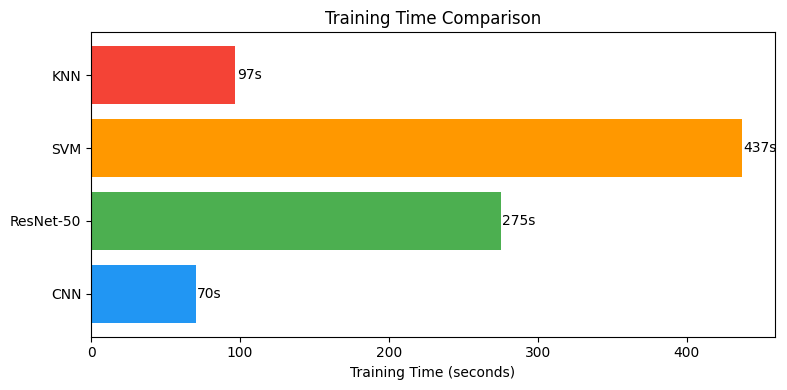

In [ ]:
# Training time comparison
fig, ax = plt.subplots(figsize=(8, 4))
times = comparison['Train Time (s)']
bars = ax.barh(times.index, times.values, color=['#2196F3', '#4CAF50', '#FF9800', '#F44336'])
ax.set_xlabel('Training Time (seconds)')
ax.set_title('Training Time Comparison')
for bar, val in zip(bars, times.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}s', va='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## 10 — Summary & Observations

| Aspect | Winner | Notes |
|--------|--------|-------|
| **Best accuracy** | CNN (92.66 %) | Custom CNN clearly outperformed all other models |
| **Second best** | ResNet-50 (72.80 %) | Transfer learning helped but limited by 64×64 resize |
| **Traditional ML** | SVM (65.54 %) > KNN (33.78 %) | SVM generalises much better on flattened pixels |
| **Fastest training** | CNN (71.6 s) | Fast *and* most accurate — best overall trade-off |
| **Slowest training** | SVM (444.9 s) | Grid search over RBF/poly kernels is expensive |

**Key take-aways:**
- **CNN is the clear winner** with 92.66 % accuracy and an F1-score of 0.9266, while training in only 71.6 s — the best accuracy-to-time trade-off.
- **ResNet-50 under-performed expectations** (72.80 % accuracy). Resizing tiny 32×32 GTSRB images to 64×64 and using ImageNet-pretrained weights offered limited benefit; the domain gap between ImageNet and traffic signs is significant.
- **SVM delivered reasonable traditional-ML results** (65.54 %) using an RBF kernel with C = 10, but flattening images discards spatial structure that CNNs naturally exploit.
- **KNN struggled the most** (33.78 %) because pixel-level Euclidean/Manhattan distance is a poor similarity metric for image classification with 43 classes.
- Flattening images discards spatial information → KNN / SVM are fundamentally limited for this task.
- Data augmentation (rotation, zoom, brightness jitter) was applied to the deep-learning models and contributed to CNN's strong performance.
- A larger input resolution and longer fine-tuning schedule could improve ResNet-50's results significantly.
